# Exploratory Data Analysis (EDA)

## Questionnaire for Refugees and Host Community Members

Prepared by:
Yusuf Olatayo Kareem

Date:
July 2026

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 100)

**Dataset Overview**

In [3]:
file = "sample_data/Questionnaire.xlsx"

df = pd.read_excel(file)
total_rows = len(df)

df.head()

,Timestamp,Age,Gender,Nationality,How long have you lived in Nigeria? (For Cameroonian refugees only),How long have you been in this community since Cameroonians came (Nigerians only)?,What was the primary reason for leaving Cameroon?,Did you come to Nigeria alone or with family?,Do you feel safe in your current location?,Have you or someone you know experienced security threats or conflicts in Nigeria?,Have there been any reported incidents of crime or violence involving refugees and local communities?,How would you describe the relationship between Cameroonian refugees and Nigerians?,What are the major security concerns faced by Cameroonian refugees in Nigeria?,What are the major security concerns faced by Nigerians as a result of the presence of refugees? (Nigerians Only),"Are there opportunities for Cameroonian refugees to integrate into Nigerian society (e.g., work, education, social support)?",What support do you think the Nigerian government should provide to both refugees and host communities to improve security?,Do you have any recommendations on how to improve relations between Cameroonian refugees and Nigerians?
0,2026-01-28 16:49:02.649,B) 26-35,A) Male,A) Cameroonian,D) More than 6 years,6 years,B) Economic hardship,B) With family,B) No (If no explain below),A) Yes,A) Yes,B) Neutral,C) Economic exploitation,Constant stealing of farm produce by refugees,B) NO (If No select Other and explain),A) More security presence,I suggest join security operatives between host community and refugees
1,2026-01-28 17:04:44.374,B) 26-35,B) Female,A) Cameroonian,D) More than 6 years,About 7years,A) Conflict/Insecurity,B) With family,A) Yes,B) NO,B) No,B) Neutral,A) Harassment by security forces,None,B) NO (If No select Other and explain),B) Livelihood programs,Identity cards should be issued to reduce harassment by security forces and immigration officers
2,2026-01-28 17:19:31.528,B) 26-35,A) Male,A) Cameroonian,D) More than 6 years,7 years,A) Conflict/Insecurity,B) With family,A) Yes,B) NO,B) No,B) Neutral,A) Harassment by security forces,Increase in population of the country leading to the rapid consumption of available consumer goo...,A) Yes,B) Livelihood programs,I recommend Cameroonians(Refugees) be given political liberty since they are affected by governm...
3,2026-01-28 17:42:15.310,B) 26-35,A) Male,A) Cameroonian,D) More than 6 years,2018,A) Conflict/Insecurity,B) With family,B) No (If no explain below),A) Yes,A) Yes,C) Tense,B) Attacks by locals,Tense,A) Yes,B) Livelihood programs,The security post should be put in place around the closest host community because they are the ...
4,2026-01-28 18:43:01.506,D) 46-60,A) Male,A) Cameroonian,D) More than 6 years,I am Cameroonian refugee,C) Political persecution,B) With family,B) No (If no explain below),A) Yes,A) Yes,B) Neutral,"Besides Harrassment by security forces,we also have attacks on refugees and refugee communities ...",I am Cameroonian,The Nigerian Government besides opportunities for refugee integration should also without delay ...,A) More security presence,Yes. . Recommendations for Improving Relations Between Cameroonian Refugees and Host Communities...


**Dataset Overview**

In [4]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 185
Columns: 17


In [6]:
# -----------------------------
# Questions with expected missing values
# (due to questionnaire skip logic)
# -----------------------------
skip_logic_questions = [
    "4. How long have you lived in Nigeria? (For Cameroonian refugees only)",
    "Ko5. How long have you been in this community since Cameroonians came (Nigerians only)?",
    "\n6. What was the primary reason for leaving Cameroon?",
    "7.  Did you come to Nigeria alone or with family?",
    "13.  What are the major security concerns faced by Nigerians as a result of the presence of refugees? (Nigerians Only)"
]


In [8]:
# -----------------------------
# Missing Value Summary
# -----------------------------
missing_count = df.isnull().sum()
non_missing = df.notnull().sum()

missing_percent = (missing_count / total_rows * 100).round(2)
completeness = (100 - missing_percent).round(2)

missing_summary = pd.DataFrame({
    "Column": df.columns,
    "Responses": total_rows,
    "Non-Missing": non_missing.values,
    "Missing": missing_count.values,
    "Missing (%)": missing_percent.values,
    "Completeness (%)": completeness.values
})


In [9]:
# -----------------------------
# Expected Missing?
# -----------------------------
missing_summary["Expected Missing"] = missing_summary["Column"].isin(skip_logic_questions)

In [12]:
# -----------------------------
# Interpretation
# -----------------------------
def interpret(row):
    if row["Missing"] == 0:
        return "✅ Complete"

    if row["Expected Missing"]:
        return "ℹ️ Expected (Skip Logic)"

    pct = row["Missing (%)"]

    if pct <= 5:
        return "🟢 Very Low Missing"

    elif pct <= 10:
        return "🟡 Low Missing"

    elif pct <= 20:
        return "🟠 Moderate Missing"

    else:
        return "🔴 High Missing"

missing_summary["Interpretation"] = missing_summary.apply(
    interpret,
    axis=1
)

In [13]:
# -----------------------------
# Sort by Missing %
# -----------------------------
missing_summary = missing_summary.sort_values(
    by="Missing (%)",
    ascending=False
).reset_index(drop=True)

In [14]:
# -----------------------------
# Display in Notebook
# -----------------------------
display(
    missing_summary.style.format({
        "Missing (%)": "{:.2f}%",
        "Completeness (%)": "{:.2f}%"
    })
)


,Column,Responses,Non-Missing,Missing,Missing (%),Completeness (%),Expected Missing,Interpretation
0,What are the major security concerns faced by Nigerians as a result of the presence of refugees? (Nigerians Only),185,66,119,64.32%,35.68%,False,🔴 High Missing
1,How long have you been in this community since Cameroonians came (Nigerians only)?,185,77,108,58.38%,41.62%,False,🔴 High Missing
2,What was the primary reason for leaving Cameroon?,185,123,62,33.51%,66.49%,False,🔴 High Missing
3,Did you come to Nigeria alone or with family?,185,124,61,32.97%,67.03%,False,🔴 High Missing
4,How long have you lived in Nigeria? (For Cameroonian refugees only),185,124,61,32.97%,67.03%,False,🔴 High Missing
5,Have you or someone you know experienced security threats or conflicts in Nigeria?,185,130,55,29.73%,70.27%,False,🔴 High Missing
6,Do you feel safe in your current location?,185,143,42,22.70%,77.30%,False,🔴 High Missing
7,What are the major security concerns faced by Cameroonian refugees in Nigeria?,185,144,41,22.16%,77.84%,False,🔴 High Missing
8,Do you have any recommendations on how to improve relations between Cameroonian refugees and Nigerians?,185,180,5,2.70%,97.30%,False,🟢 Very Low Missing
9,Timestamp,185,185,0,0.00%,100.00%,False,✅ Complete


**Missing Value Summary**

**Dataset Summary**

In [33]:
summary = pd.DataFrame({
    "Total Rows":[len(df)],
    "Total Columns":[df.shape[1]],
    "Duplicate Rows":[df.duplicated().sum()],
    "Columns with Missing":[sum(df.isnull().sum()>0)]
})

summary

,Total Rows,Total Columns,Duplicate Rows,Columns with Missing
0,185,17,0,9


**Variable Information**

In [34]:
info = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Non-null": df.count().values,
    "Unique Values": df.nunique().values
})

info

,Column,Data Type,Non-null,Unique Values
0,Timestamp,datetime64[ns],185,185
1,1. Age,object,185,5
2,2. Gender:,object,185,2
3,3. Nationality:,object,185,2
4,4. How long have you lived in Nigeria? (For Cameroonian refugees only),object,124,4
5,Ko5. How long have you been in this community since Cameroonians came (Nigerians only)?,object,77,32
6,\n6. What was the primary reason for leaving Cameroon?,object,123,4
7,7. Did you come to Nigeria alone or with family?,object,124,2
8,8. Do you feel safe in your current location?,object,143,35
9,9. Have you or someone you know experienced security threats or conflicts in Nigeria?,object,130,2


**Visualizations for Missing values**

<Axes: >

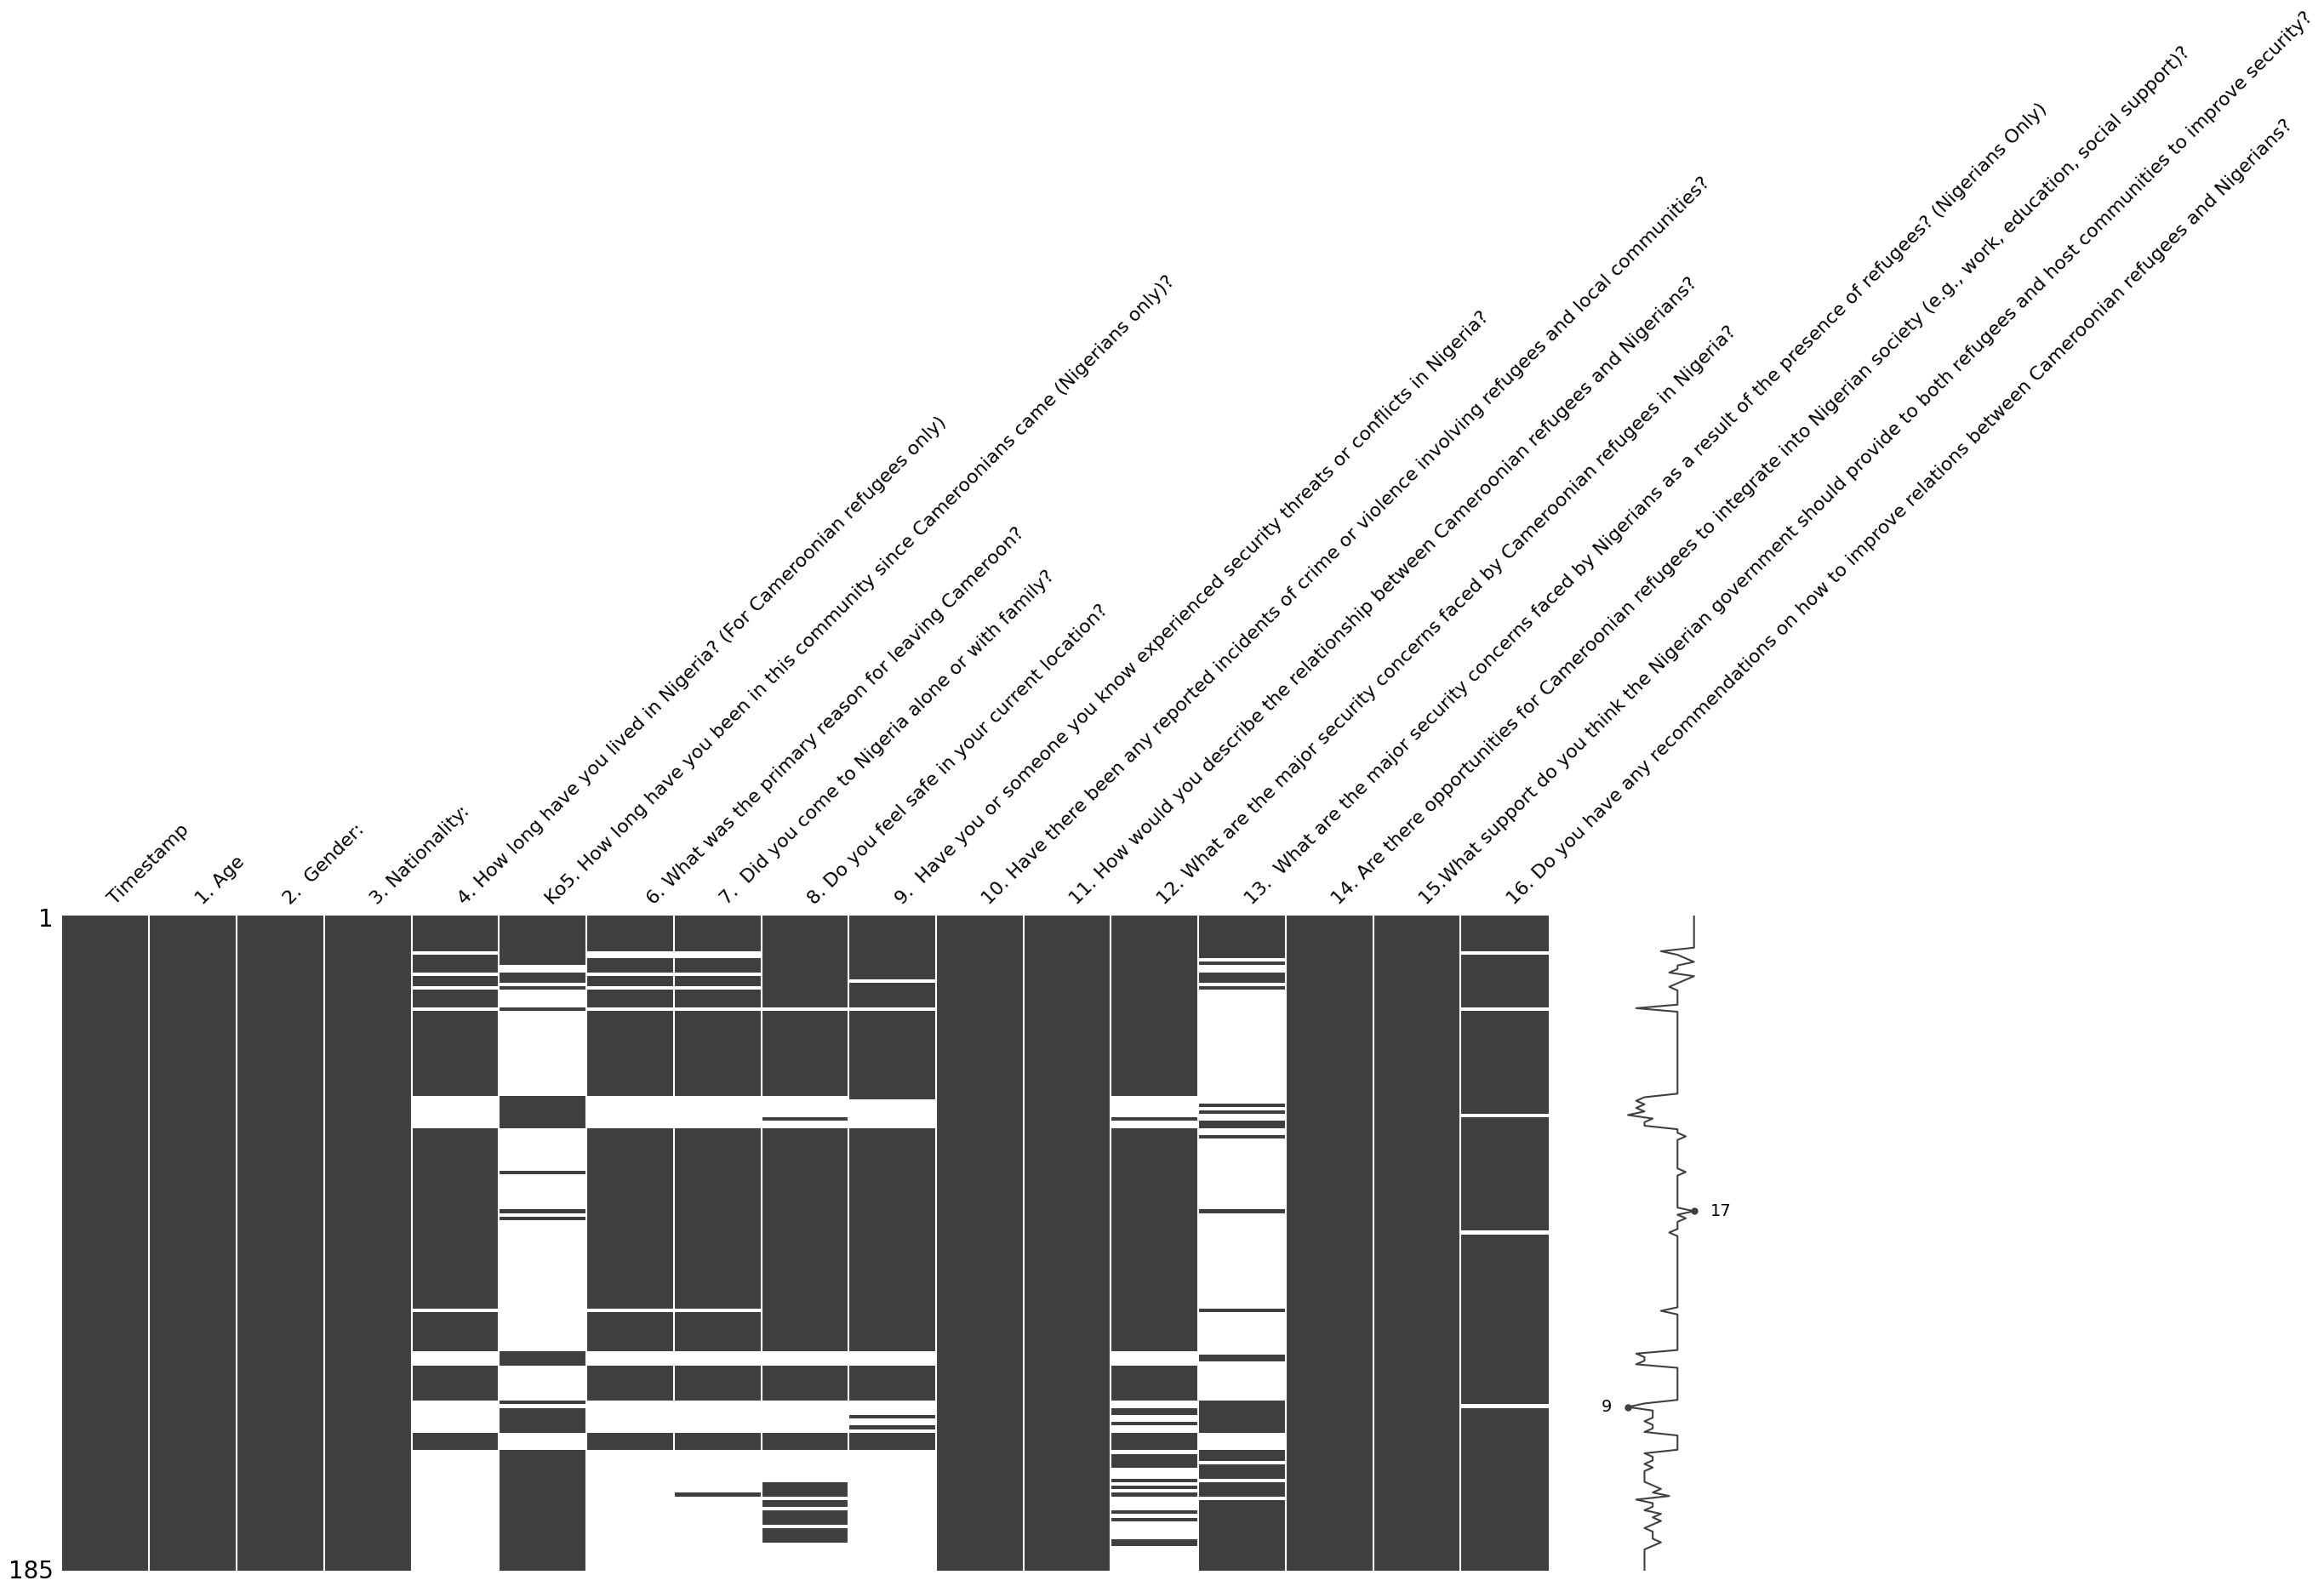

In [23]:
import missingno as msno

msno.matrix(df)

In [15]:
df["2.  Gender:"].value_counts().to_frame()

,count
2. Gender:,
A) Male,96
B) Female,89


In [15]:
import pandas as pd
import re

def frequency_table(df, column, show_total=False):
    # Calculate frequency
    freq = df[column].value_counts(dropna=False)

    table = pd.DataFrame({
        column: freq.index,
        "Frequency": freq.values,
        "Percentage (%)": (freq.values / len(df) * 100).round(2)
    })

    # Replace missing values with "NA"
    table[column] = (
        table[column]
        .replace([None], pd.NA)
        .fillna("NA")
        .astype(str)
        .replace({"nan": "NA", "None": "NA", "": "NA"})
    )

    # Pattern for questionnaire options
    pattern = r"^([A-Za-z])[\)\.\:\-]\s*"

    # Ignore NA when checking whether the column contains options
    non_na = table.loc[table[column] != "NA", column]

    has_options = (
        len(non_na) > 0 and
        non_na.str.match(pattern).all()
    )

    if has_options:
        # Extract option letters
        table["Option"] = (
            table[column]
            .str.extract(pattern)[0]
            .str.upper()
        )

        # Remove option prefixes
        table[column] = table[column].str.replace(pattern, "", regex=True)

        # Give NA a sorting key after Z
        table["_sort"] = table["Option"].fillna("ZZ")

        table = (
            table.sort_values("_sort")
                 .drop(columns="_sort")
        )

        # Show NA instead of blank option
        table["Option"] = table["Option"].fillna("")

        table = table[["Option", column, "Frequency", "Percentage (%)"]]

    # Add total row if requested
    if show_total:
        total_row = {}

        if has_options:
            total_row["Option"] = ""
            total_row[column] = "Total"
        else:
            total_row[column] = "Total"

        total_row["Frequency"] = table["Frequency"].sum()
        total_row["Percentage (%)"] = table["Percentage (%)"].sum().round(2)

        table = pd.concat(
            [table, pd.DataFrame([total_row])],
            ignore_index=True
        )

    return table.reset_index(drop=True)

In [16]:
def recode_years_to_category(df, source_col, new_col):
    """
    Recode years into questionnaire categories:
        A) Less than 1 year
        B) 1-3 years
        C) 4-6 years
        D) More than 6 years
        NA
    """

    current_year = pd.Timestamp.now().year

    word_to_num = {
        "one": 1,
        "two": 2,
        "three": 3,
        "four": 4,
        "five": 5,
        "six": 6,
        "seven": 7,
        "eight": 8,
        "nine": 9,
        "ten": 10,
        "eleven": 11,
        "twelve": 12,
        "thirteen": 13
    }

    def classify(value):

        # Missing values
        if pd.isna(value):
            return "NA"

        text = str(value).strip().lower()

        if text in ["", "na", "nan", "none"]:
            return "NA"

        # Cameroonian or not applicable
        if any(x in text for x in [
            "cameroon",
            "cameroonian",
            "not living",
            "born here",
            "before they came"
        ]):
            return "NA"

        # Replace words with numbers
        for word, num in word_to_num.items():
            text = re.sub(rf"\b{word}\b", str(num), text)

        # Handle calendar years (e.g. Since 2017, 2018)
        year = re.search(r"\b(20\d{2})\b", text)
        if year:
            years = current_year - int(year.group())
        else:
            # First number found
            num = re.search(r"\d+", text)
            if num:
                years = int(num.group())
            else:
                return "NA"

        # Categorize
        if years < 1:
            return "A) Less than 1 year"
        elif years <= 3:
            return "B) 1-3 years"
        elif years <= 6:
            return "C) 4-6 years"
        else:
            return "D) More than 6 years"

    df[new_col] = df[source_col].apply(classify)

    return df

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_frequency_bar(
    table,
    category_col,
    frequency_col="Frequency",
    title=None,
    xlabel=None,
    ylabel="Frequency",
    figsize=(8, 5),
    color="steelblue"
):
    """
    Plot a bar chart from a frequency table.

    Parameters
    ----------
    table : pd.DataFrame
        Frequency table generated by frequency_table().
    category_col : str
        Name of the categorical column (e.g., 'Age', 'Gender').
    frequency_col : str, default='Frequency'
        Name of the frequency column.
    title : str, optional
        Chart title.
    xlabel : str, optional
        X-axis label. Defaults to category_col.
    ylabel : str, default='Frequency'
        Y-axis label.
    figsize : tuple, default=(8,5)
        Figure size.
    color : str, default='steelblue'
        Bar color.
    """

    # Exclude Total row if present
    plot_data = table[table[category_col] != "Total"].copy()
     # White background (same as your previous plots)
    sns.set_style("white")
    plt.figure(figsize=figsize)

    sns.barplot(
        data=plot_data,
        x=category_col,
        y=frequency_col,
        color=color
    )

    plt.title(title if title else f"Distribution of Respondents by {category_col}")
    plt.xlabel(xlabel if xlabel else category_col)
    plt.ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [29]:
import matplotlib.pyplot as plt

def plot_frequency_pie(
    table,
    category_col,
    frequency_col="Frequency",
    title=None,
    figsize=(6, 6),
    autopct="%1.1f%%",
    startangle=90
):
    """
    Plot a pie chart from a frequency table.

    Parameters
    ----------
    table : pd.DataFrame
        Frequency table generated by frequency_table().
    category_col : str
        Name of the categorical column (e.g., 'Age', 'Gender').
    frequency_col : str, default='Frequency'
        Name of the frequency column.
    title : str, optional
        Chart title.
    figsize : tuple, default=(6, 6)
        Figure size.
    autopct : str, default='%1.1f%%'
        Percentage format for pie labels.
    startangle : int, default=90
        Starting angle of the pie chart.
    """

    # Exclude Total row if present
    plot_data = table[table[category_col] != "Total"].copy()

    plt.figure(figsize=figsize)

    plt.pie(
        plot_data[frequency_col],
        labels=plot_data[category_col],
        autopct=autopct,
        startangle=startangle
    )

    plt.title(title if title else f"{category_col} Distribution")

    plt.tight_layout()
    plt.show()

In [19]:
def recode_binary_question(df, source_col, new_col):
    """
    Recode questionnaire responses into:
    YES, NO, NA

    Any explanatory text is assumed to mean NO.
    """

    def recode(x):

        if pd.isna(x):
            return "NA"

        x = str(x).strip()

        if x == "":
            return "NA"

        x_lower = x.lower()

        if "yes" in x_lower:
            return "YES"

        if "no" in x_lower:
            return "NO"

        return "NO"

    df[new_col] = df[source_col].apply(recode)

    return df

In [47]:
import pandas as pd
import re

def recode_security_concerns(table, column):
    """
    Recode security concern responses into:
        A) Harassment by security forces
        B) Attacks by locals
        C) Economic exploitation
        NA

    Parameters
    ----------
    table : pd.DataFrame
        DataFrame containing the responses.
    column : str
        Name of the response column.

    Returns
    -------
    pd.DataFrame
    """

    def recode(value):

        if pd.isna(value):
            return "NA"

        text = str(value).strip()

        # Preserve Total row
        if text.lower() == "total":
            return "Total"

        if text.upper() == "NA":
            return "NA"

        lower = text.lower()

        # Already coded
        if re.match(r"^a[\)\.\:\-]", lower):
            return "A) Harassment by security forces"

        if re.match(r"^b[\)\.\:\-]", lower):
            return "B) Attacks by locals"

        if re.match(r"^c[\)\.\:\-]", lower):
            return "C) Economic exploitation"

        # Keyword matching
        if any(word in lower for word in [
            "security force",
            "security forces",
            "immigration",
            "harassment"
        ]):
            return "A) Harassment by security forces"

        if any(word in lower for word in [
            "attack",
            "locals",
            "community"
        ]):
            return "B) Attacks by locals"

        if any(word in lower for word in [
            "economic",
            "exploit",
            "exploitation",
            "exploration"
        ]):
            return "C) Economic exploitation"

        # Responses mentioning multiple concerns
        if "all three" in lower or "blend" in lower:
            return "NA"

        return "NA"

    table = table.copy()
    table[column] = table[column].apply(recode)

    return table

In [10]:
df["Age"].describe()

,Age
count,185
unique,5
top,B) 26-35
freq,49


**Age Descriptive Analysis**

In [32]:
age_table = frequency_table(df,"Age")

display(age_table)

,Option,Age,Frequency,Percentage (%)
0,A,18-25,32,17.30
1,B,26-35,49,26.49
2,C,36-45,32,17.30
3,D,46-60,49,26.49
4,E,60+,23,12.43


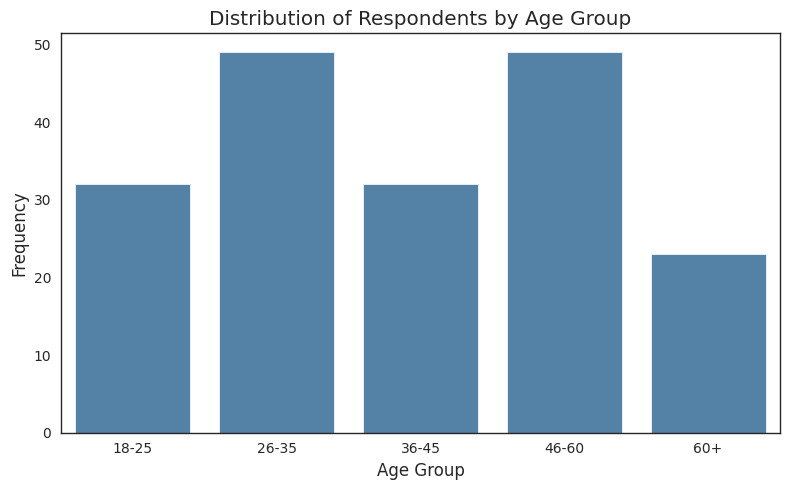

In [45]:
plot_frequency_bar(
    age_table,
    category_col="Age",
    title="Distribution of Respondents by Age Group",
    xlabel="Age Group"
)

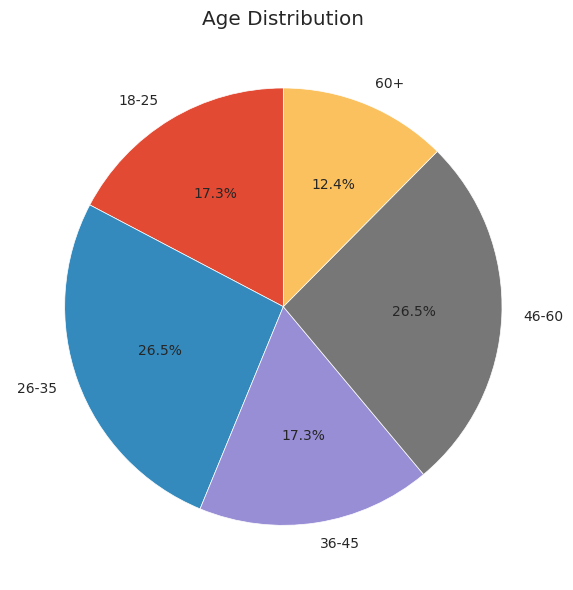

In [48]:
plot_frequency_pie(
    age_table,
    category_col="Age",
    title="Age Distribution"
)

**Gender Descriptive Analysis**

In [33]:
gender_table = frequency_table(df,"Gender",show_total=True)

display(gender_table)

,Option,Gender,Frequency,Percentage (%)
0,A,Male,96,51.89
1,B,Female,89,48.11
2,,Total,185,100.00


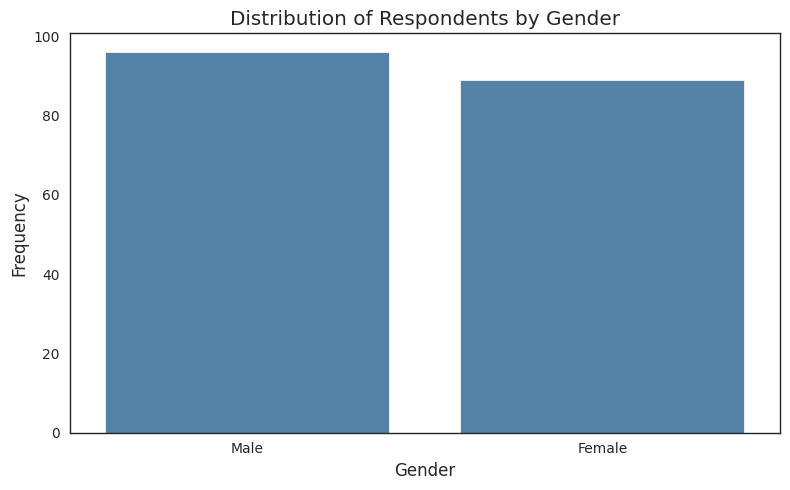

In [46]:
plot_frequency_bar(
    gender_table,
    category_col="Gender",
    title="Distribution of Respondents by Gender"
)

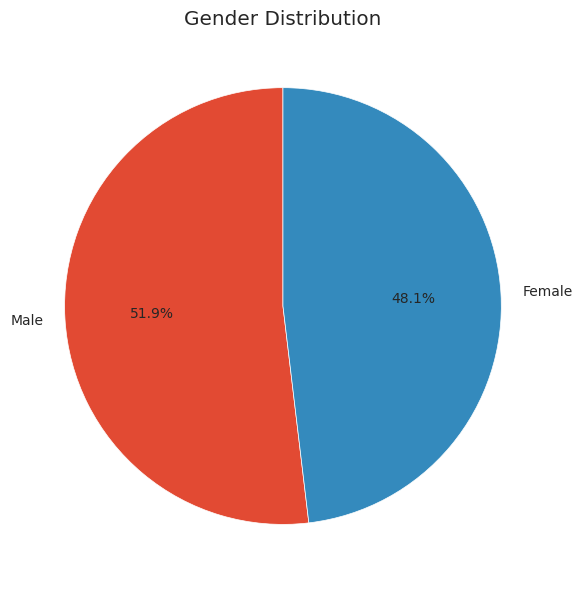

In [49]:
plot_frequency_pie(
    gender_table,
    category_col="Gender",
    title="Gender Distribution"
)

**Nationality Descriptive Analysis**

In [39]:
nationality_table = frequency_table(df,"Nationality",show_total=True)

display(nationality_table)

,Option,Nationality,Frequency,Percentage (%)
0,A,Cameroonian,122,65.95
1,B,Nigerian,63,34.05
2,,Total,185,100.00


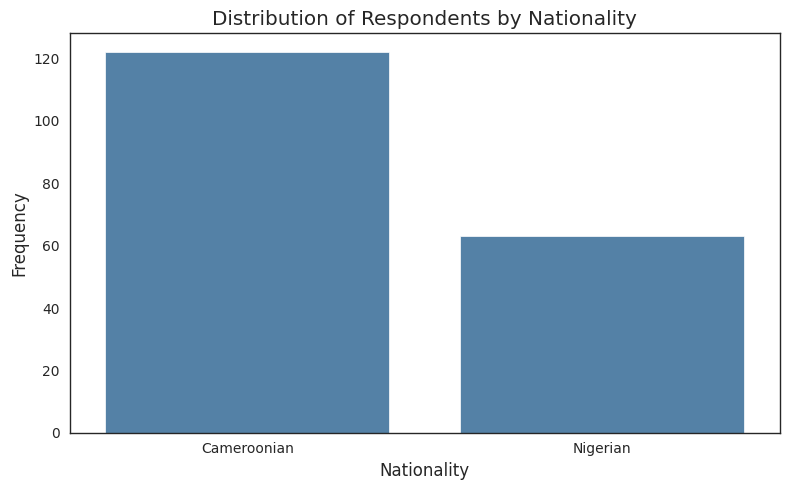

In [57]:
plot_frequency_bar(
    nationality_table,
    category_col="Nationality",
    title="Distribution of Respondents by Nationality"
)

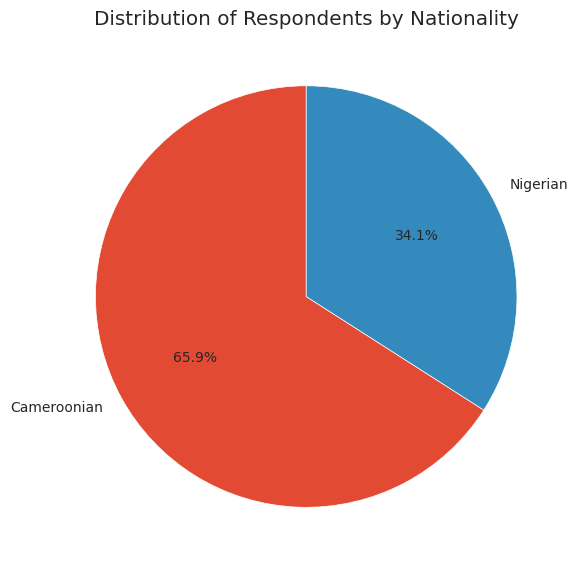

In [40]:
plot_frequency_pie(
    nationality_table,
    category_col="Nationality",
    title="Distribution of Respondents by Nationality"
)

**How long have you lived in Nigeria? (For Cameroonian refugees only) Data Analysis**

In [61]:
nationality_table = frequency_table(df,"How long have you lived in Nigeria? (For Cameroonian refugees only)",show_total=True)

display(nationality_table)

,Option,How long have you lived in Nigeria? (For Cameroonian refugees only),Frequency,Percentage (%)
0,A,Less than 1 year,2,1.08
1,B,1-3 years,9,4.86
2,C,4-6 years,30,16.22
3,D,More than 6 years,83,44.86
4,,NA,61,32.97
5,,Total,185,99.99


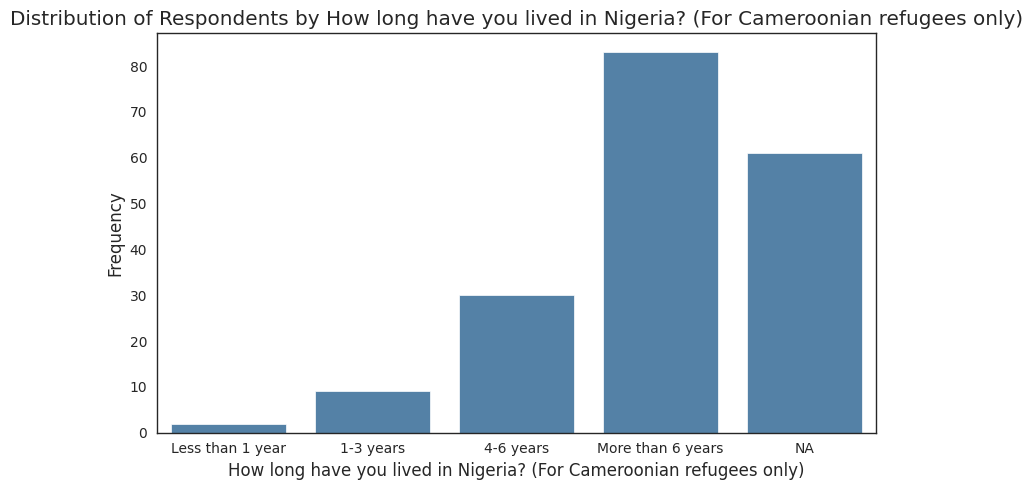

In [63]:
plot_frequency_bar(
    nationality_table,
    category_col="How long have you lived in Nigeria? (For Cameroonian refugees only)",
    title=""
)

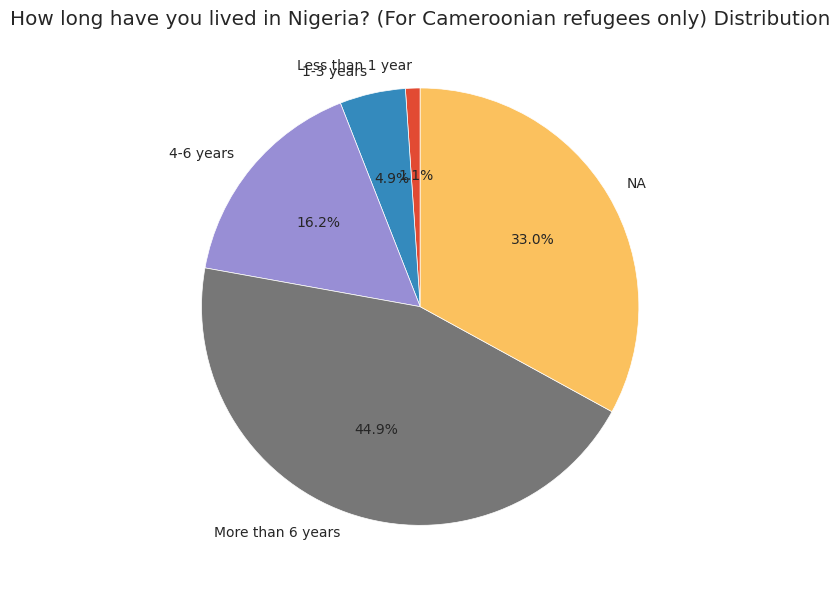

In [62]:
plot_frequency_pie(
    nationality_table,
    category_col="How long have you lived in Nigeria? (For Cameroonian refugees only)",
    title=""
)

**How long have you been in this community since Cameroonians came (Nigerians only)? **

In [67]:
years_in_community_recoded = recode_years_to_category(
    df,
    "How long have you been in this community since Cameroonians came (Nigerians only)? ",
    "Years in Community (Recoded)"
)

In [68]:
community_table = frequency_table(
    years_in_community_recoded,
    "Years in Community (Recoded)",
    show_total=True
)

display(community_table)

,Option,Years in Community (Recoded),Frequency,Percentage (%)
0,C,4-6 years,10,5.41
1,D,More than 6 years,62,33.51
2,,NA,113,61.08
3,,Total,185,100.00


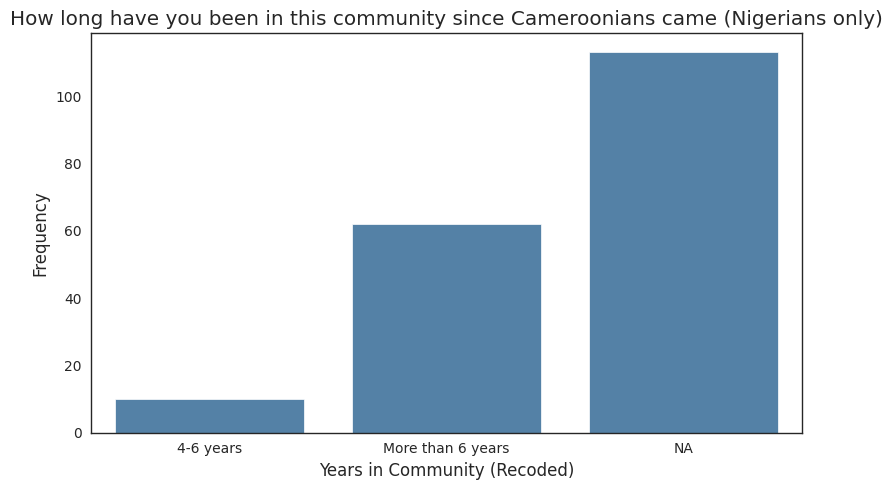

In [71]:
plot_frequency_bar(
    community_table,
    category_col="Years in Community (Recoded)",
    title="How long have you been in this community since Cameroonians came (Nigerians only)"
)

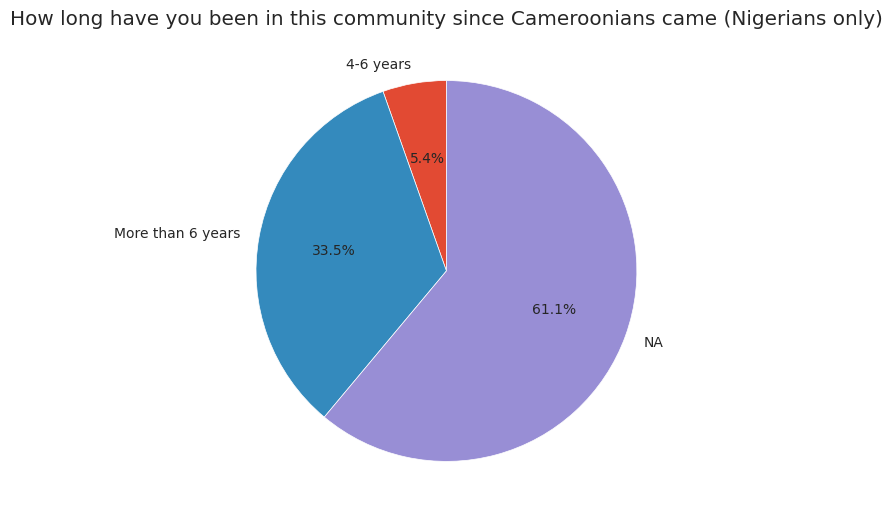

In [73]:
plot_frequency_pie(
    community_table,
    category_col="Years in Community (Recoded)",
    title="How long have you been in this community since Cameroonians came (Nigerians only)"
)

**What was the primary reason for leaving Cameroon?**

In [77]:
reason_for_leaving_cameroon_table = frequency_table(df,"What was the primary reason for leaving Cameroon?",show_total=False)

display(reason_for_leaving_cameroon_table)

,Option,What was the primary reason for leaving Cameroon?,Frequency,Percentage (%)
0,A,Conflict/Insecurity,112,60.54
1,B,Economic hardship,3,1.62
2,C,Political persecution,6,3.24
3,E,Other (please specify),2,1.08
4,,NA,62,33.51


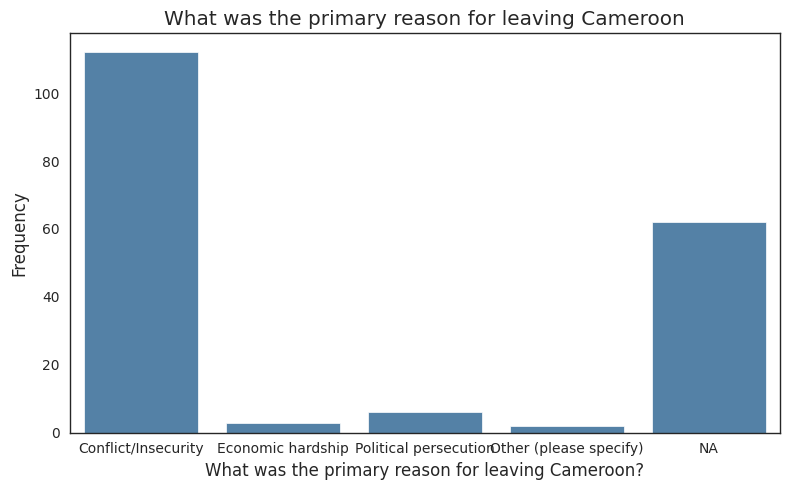

In [78]:
plot_frequency_bar(
    reason_for_leaving_cameroon_table,
    category_col="What was the primary reason for leaving Cameroon?",
    title="What was the primary reason for leaving Cameroon"
)

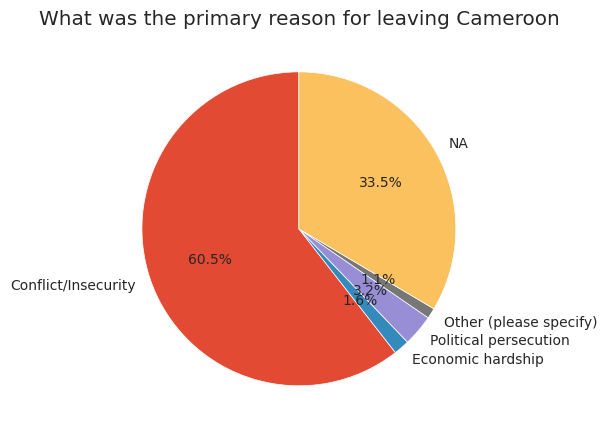

In [79]:
plot_frequency_pie(
    reason_for_leaving_cameroon_table,
    category_col="What was the primary reason for leaving Cameroon?",
    title="What was the primary reason for leaving Cameroon"
)

**Did you come to Nigeria alone or with family?**

In [81]:
from_cameroon_to_nigeria_table = frequency_table(df,"Did you come to Nigeria alone or with family?",show_total=True)

display(from_cameroon_to_nigeria_table)

,Option,Did you come to Nigeria alone or with family?,Frequency,Percentage (%)
0,A,Alone,32,17.30
1,B,With family,92,49.73
2,,NA,61,32.97
3,,Total,185,100.00


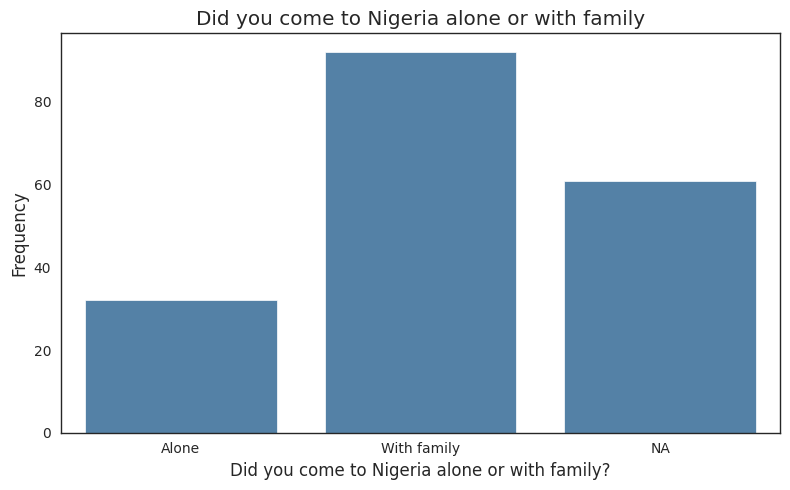

In [82]:
plot_frequency_bar(
    from_cameroon_to_nigeria_table,
    category_col="Did you come to Nigeria alone or with family?",
    title="Did you come to Nigeria alone or with family"
)

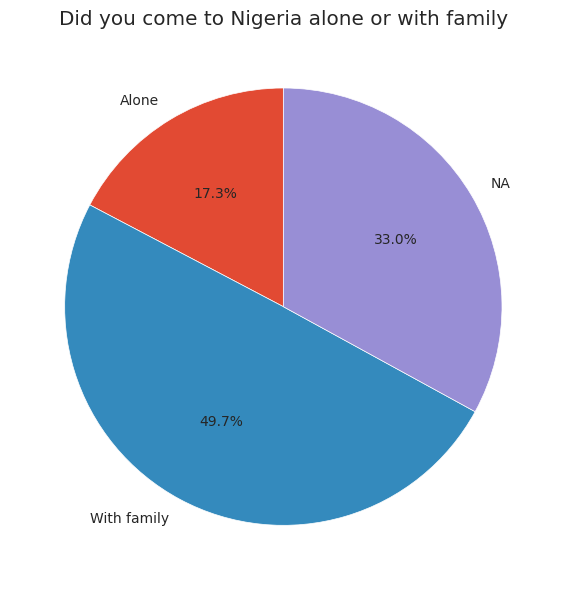

In [83]:
plot_frequency_pie(
    from_cameroon_to_nigeria_table,
    category_col="Did you come to Nigeria alone or with family?",
    title="Did you come to Nigeria alone or with family"
)

**Do you feel safe in your current location?**

In [20]:
recode_binary_question(df, "Do you feel safe in your current location?", "Do you feel safe in your current location? (Recoded)")

,Timestamp,Age,Gender,Nationality,How long have you lived in Nigeria? (For Cameroonian refugees only),How long have you been in this community since Cameroonians came (Nigerians only)?,What was the primary reason for leaving Cameroon?,Did you come to Nigeria alone or with family?,Do you feel safe in your current location?,Have you or someone you know experienced security threats or conflicts in Nigeria?,Have there been any reported incidents of crime or violence involving refugees and local communities?,How would you describe the relationship between Cameroonian refugees and Nigerians?,What are the major security concerns faced by Cameroonian refugees in Nigeria?,What are the major security concerns faced by Nigerians as a result of the presence of refugees? (Nigerians Only),"Are there opportunities for Cameroonian refugees to integrate into Nigerian society (e.g., work, education, social support)?",What support do you think the Nigerian government should provide to both refugees and host communities to improve security?,Do you have any recommendations on how to improve relations between Cameroonian refugees and Nigerians?,Do you feel safe in your current location? (Recoded)
0,2026-01-28 16:49:02.649,B) 26-35,A) Male,A) Cameroonian,D) More than 6 years,6 years,B) Economic hardship,B) With family,B) No (If no explain below),A) Yes,A) Yes,B) Neutral,C) Economic exploitation,Constant stealing of farm produce by refugees,B) NO (If No select Other and explain),A) More security presence,I suggest join security operatives between host community and refugees,NO
1,2026-01-28 17:04:44.374,B) 26-35,B) Female,A) Cameroonian,D) More than 6 years,About 7years,A) Conflict/Insecurity,B) With family,A) Yes,B) NO,B) No,B) Neutral,A) Harassment by security forces,None,B) NO (If No select Other and explain),B) Livelihood programs,Identity cards should be issued to reduce harassment by security forces and immigration officers,YES
2,2026-01-28 17:19:31.528,B) 26-35,A) Male,A) Cameroonian,D) More than 6 years,7 years,A) Conflict/Insecurity,B) With family,A) Yes,B) NO,B) No,B) Neutral,A) Harassment by security forces,Increase in population of the country leading to the rapid consumption of available consumer goo...,A) Yes,B) Livelihood programs,I recommend Cameroonians(Refugees) be given political liberty since they are affected by governm...,YES
3,2026-01-28 17:42:15.310,B) 26-35,A) Male,A) Cameroonian,D) More than 6 years,2018,A) Conflict/Insecurity,B) With family,B) No (If no explain below),A) Yes,A) Yes,C) Tense,B) Attacks by locals,Tense,A) Yes,B) Livelihood programs,The security post should be put in place around the closest host community because they are the ...,NO
4,2026-01-28 18:43:01.506,D) 46-60,A) Male,A) Cameroonian,D) More than 6 years,I am Cameroonian refugee,C) Political persecution,B) With family,B) No (If no explain below),A) Yes,A) Yes,B) Neutral,"Besides Harrassment by security forces,we also have attacks on refugees and refugee communities ...",I am Cameroonian,The Nigerian Government besides opportunities for refugee integration should also without delay ...,A) More security presence,Yes. . Recommendations for Improving Relations Between Cameroonian Refugees and Host Communities...,NO
5,2026-01-28 19:22:24.792,B) 26-35,B) Female,A) Cameroonian,D) More than 6 years,8 years,A) Conflict/Insecurity,B) With family,The host community is becoming very hostile,A) Yes,A) Yes,B) Neutral,B) Attacks by locals,Economic threat,A) Yes,B) Livelihood programs,We will integrate with the host communities and try to leave in one.,NO
6,2026-01-28 20:19:25.493,D) 46-60,A) Male,A) Cameroonian,D) More than 6 years,Eight years,A) Conflict/Insecurity,B) With family,A) Yes,A) Yes,B) No,A) Friendly,A) Harassment by security forces,In adequate resources like accommodation in the border communities. Thus incredible rise in rents.,A) Yes,B) Livelihood programs,Yes. The police and the immigration officers should stop harassing refugees who are in possessio...

In [22]:
feel_safe_table = frequency_table(df,"Do you feel safe in your current location? (Recoded)",show_total=True)

display(feel_safe_table)

,Do you feel safe in your current location? (Recoded),Frequency,Percentage (%)
0,NO,73,39.46
1,YES,70,37.84
2,NA,42,22.70
3,Total,185,100.00


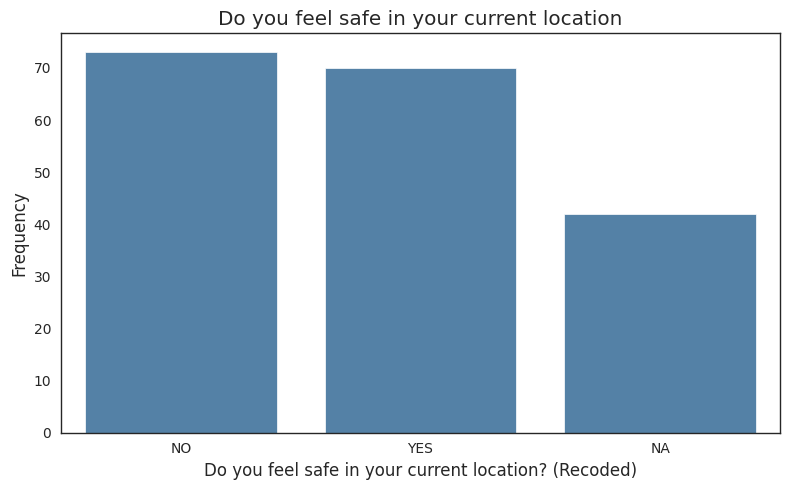

In [26]:
plot_frequency_bar(
    feel_safe_table,
    category_col="Do you feel safe in your current location? (Recoded)",
    title="Do you feel safe in your current location"
)

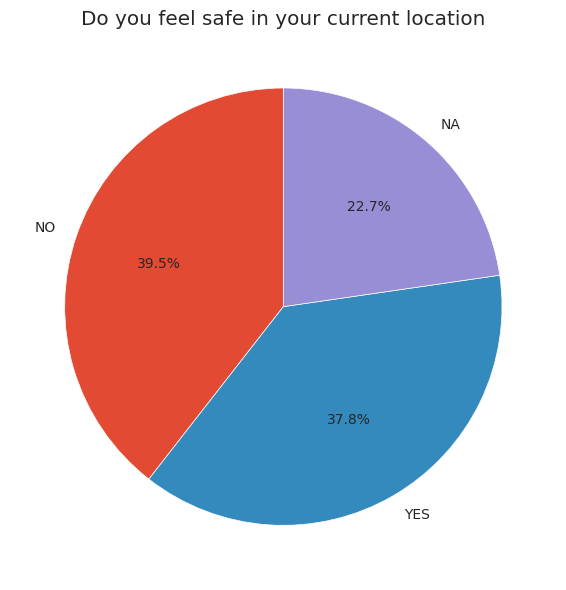

In [30]:
plot_frequency_pie(
    feel_safe_table,
    category_col="Do you feel safe in your current location? (Recoded)",
    title="Do you feel safe in your current location"
)

**Have you or someone you know experienced security threats or conflicts in Nigeria?**

In [31]:
security_threats_table = frequency_table(df,"Have you or someone you know experienced security threats or conflicts in Nigeria?",show_total=True)

display(security_threats_table)

,Option,Have you or someone you know experienced security threats or conflicts in Nigeria?,Frequency,Percentage (%)
0,A,Yes,108,58.38
1,B,NO,22,11.89
2,,NA,55,29.73
3,,Total,185,100.00


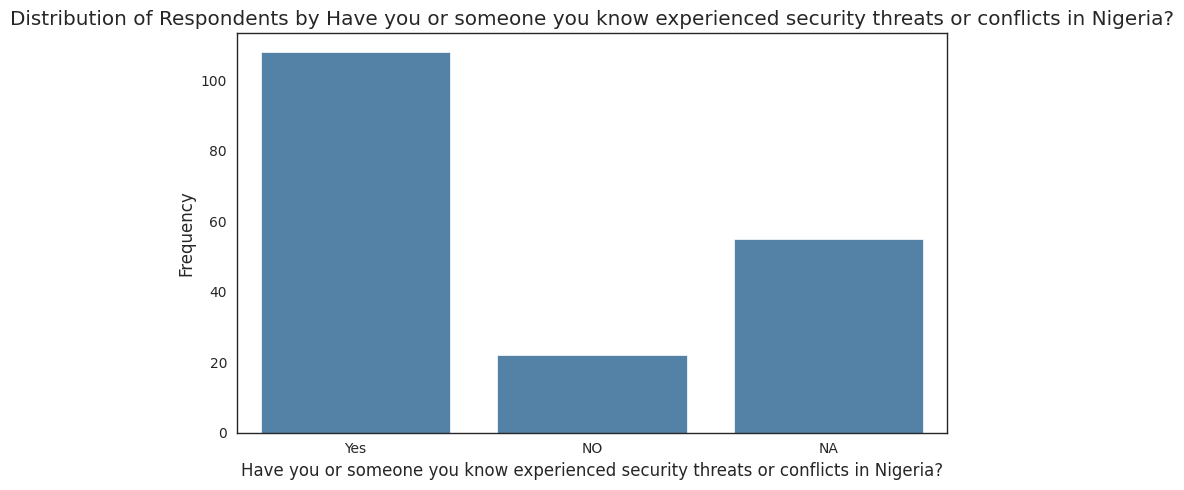

In [33]:
plot_frequency_bar(
    security_threats_table,
    category_col="Have you or someone you know experienced security threats or conflicts in Nigeria?",
    title=""
)

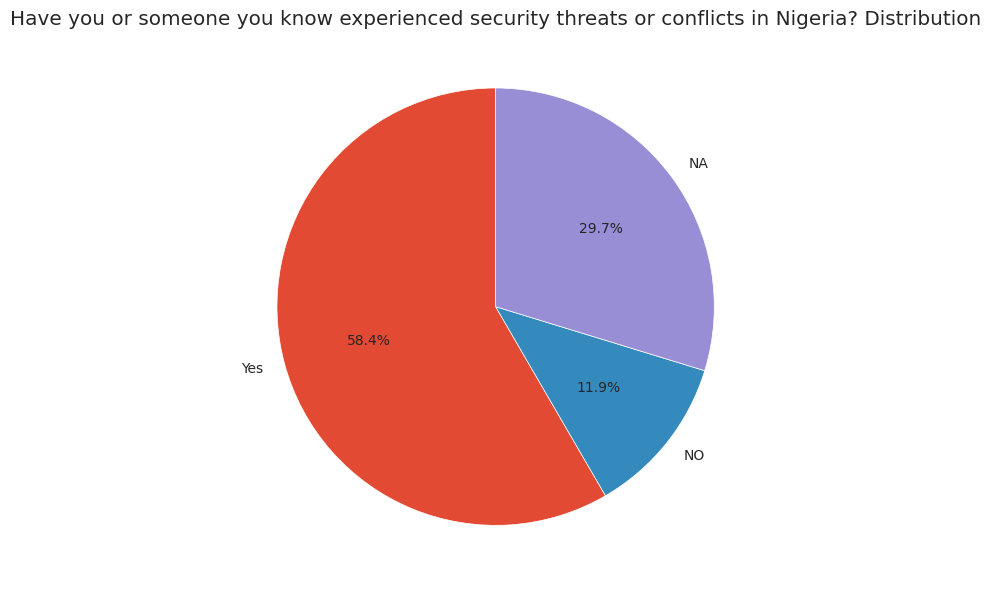

In [35]:
plot_frequency_pie(
    security_threats_table,
    category_col="Have you or someone you know experienced security threats or conflicts in Nigeria?",
    title=""
)

**Have there been any reported incidents of crime or violence involving refugees and local communities?**

In [36]:
incident_table = frequency_table(df,"Have there been any reported incidents of crime or violence involving refugees and local communities?",show_total=True)

display(incident_table)

,Option,Have there been any reported incidents of crime or violence involving refugees and local communities?,Frequency,Percentage (%)
0,A,Yes,167,90.27
1,B,No,18,9.73
2,,Total,185,100.00


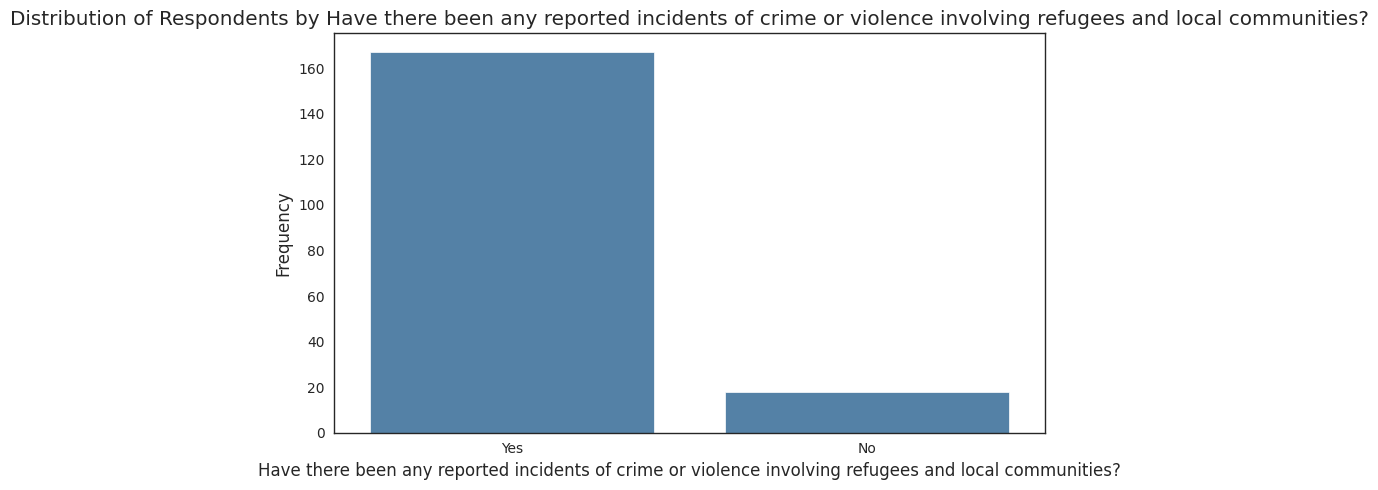

In [41]:
plot_frequency_bar(
    incident_table,
    category_col="Have there been any reported incidents of crime or violence involving refugees and local communities?",
    title=""
)

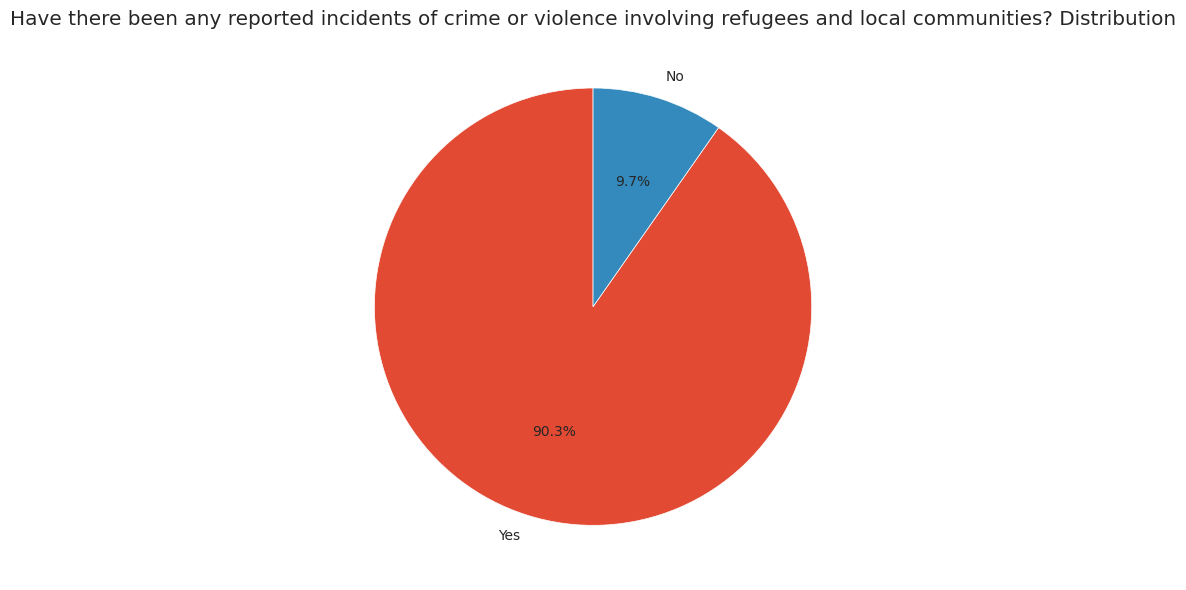

In [42]:
plot_frequency_pie(
    incident_table,
    category_col="Have there been any reported incidents of crime or violence involving refugees and local communities?",
    title=""
)

**How would you describe the relationship between Cameroonian refugees and Nigerians?**

In [43]:
cam_nig_table = frequency_table(df,"How would you describe the relationship between Cameroonian refugees and Nigerians?",show_total=True)

display(cam_nig_table)

,Option,How would you describe the relationship between Cameroonian refugees and Nigerians?,Frequency,Percentage (%)
0,A,Friendly,91,49.19
1,B,Neutral,76,41.08
2,C,Tense,18,9.73
3,,Total,185,100.00


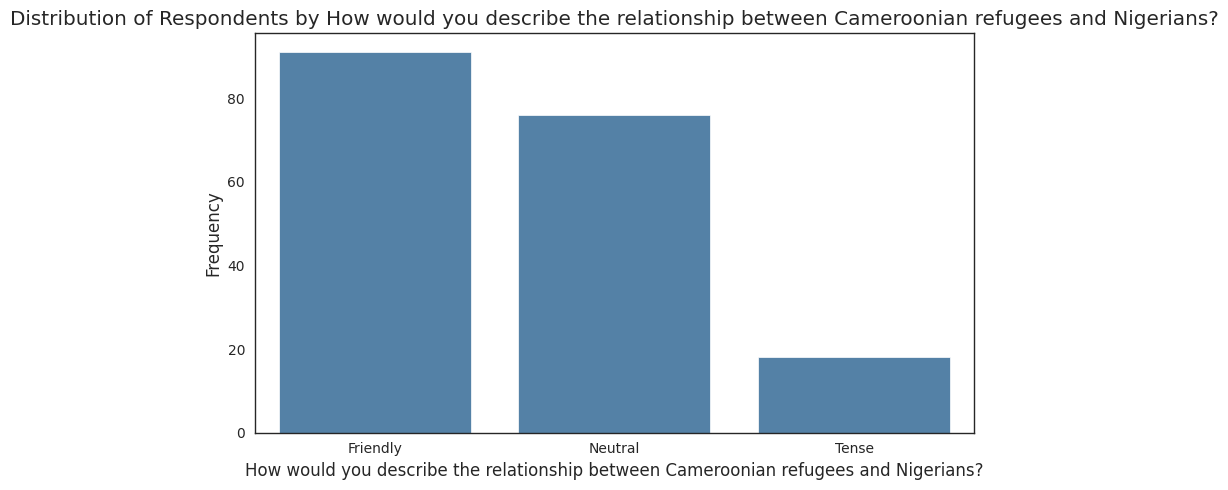

In [44]:
plot_frequency_bar(
    cam_nig_table,
    category_col="How would you describe the relationship between Cameroonian refugees and Nigerians?",
    title=""
)

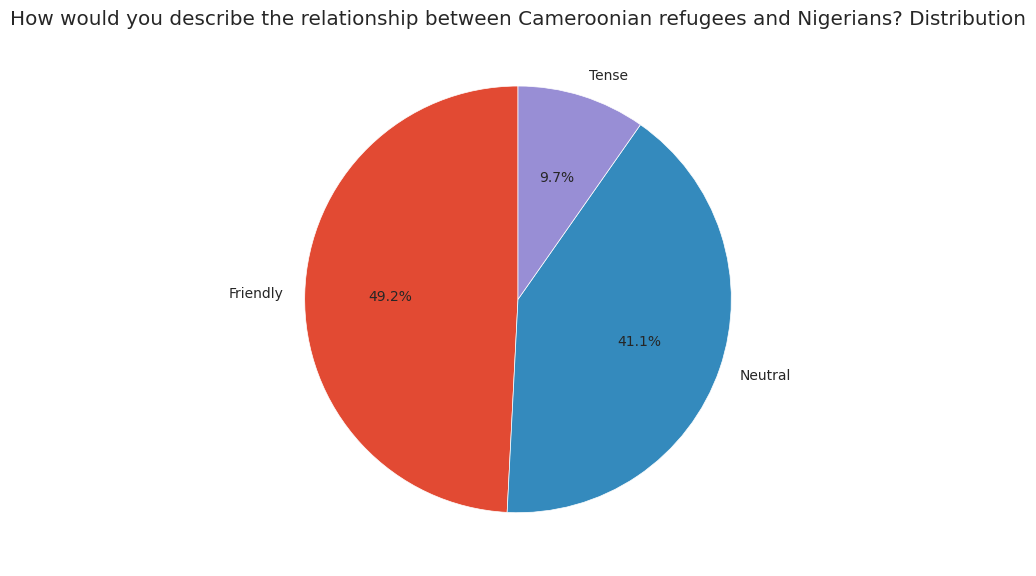

In [45]:
plot_frequency_pie(
    cam_nig_table,
    category_col="How would you describe the relationship between Cameroonian refugees and Nigerians?",
    title=""
)

**What are the major security concerns faced by Cameroonian refugees in Nigeria?**

In [48]:
df_rcoded = recode_security_concerns(
    df,
    "What are the major security concerns faced by Cameroonian refugees in Nigeria?"
)

In [49]:
security_concern_table = frequency_table(df_rcoded,"What are the major security concerns faced by Cameroonian refugees in Nigeria?",show_total=True)

display(security_concern_table)

,Option,What are the major security concerns faced by Cameroonian refugees in Nigeria?,Frequency,Percentage (%)
0,A,Harassment by security forces,58,31.35
1,B,Attacks by locals,29,15.68
2,C,Economic exploitation,55,29.73
3,,NA,43,23.24
4,,Total,185,100.00


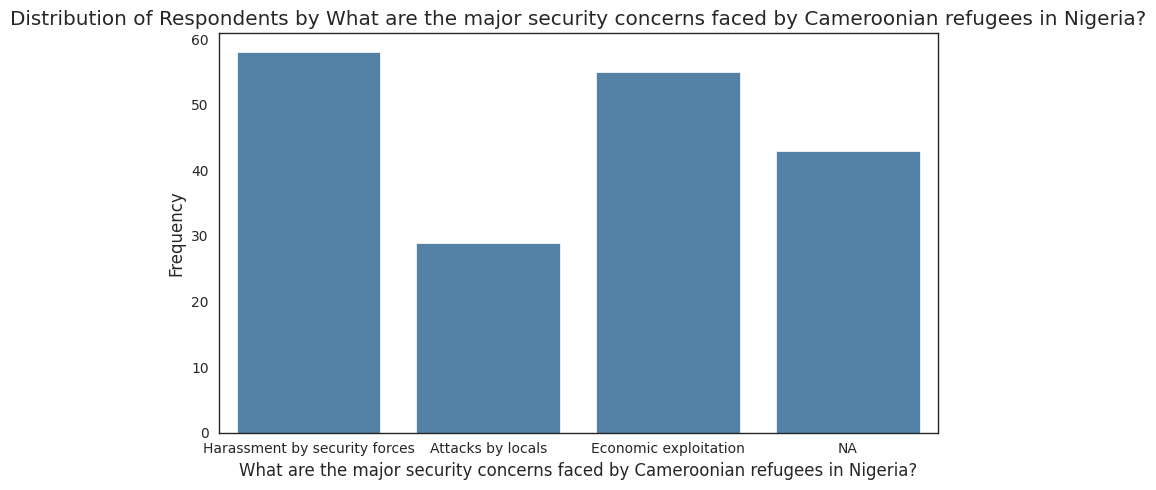

In [50]:
plot_frequency_bar(
    security_concern_table,
    category_col="What are the major security concerns faced by Cameroonian refugees in Nigeria?",
    title=""
)

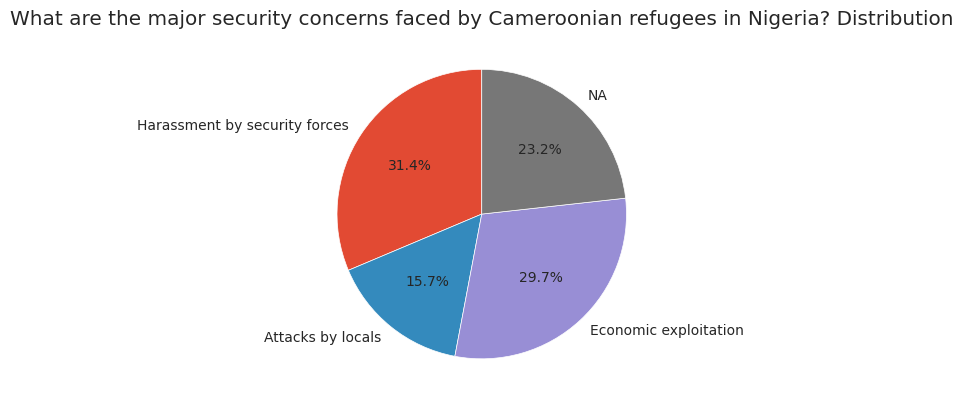

In [51]:
plot_frequency_pie(
    security_concern_table,
    category_col="What are the major security concerns faced by Cameroonian refugees in Nigeria?",
    title=""
)

**Are there opportunities for Cameroonian refugees to integrate into Nigerian society (e.g., work, education, social support)?**

In [55]:
recode_binary_question(df, "Are there opportunities for Cameroonian refugees to integrate into Nigerian society (e.g., work, education, social support)?", "Are there opportunities for Cameroonian refugees to integrate into Nigerian society (e.g., work, education, social support)? (Recoded)")

,Timestamp,Age,Gender,Nationality,How long have you lived in Nigeria? (For Cameroonian refugees only),How long have you been in this community since Cameroonians came (Nigerians only)?,What was the primary reason for leaving Cameroon?,Did you come to Nigeria alone or with family?,Do you feel safe in your current location?,Have you or someone you know experienced security threats or conflicts in Nigeria?,Have there been any reported incidents of crime or violence involving refugees and local communities?,How would you describe the relationship between Cameroonian refugees and Nigerians?,What are the major security concerns faced by Cameroonian refugees in Nigeria?,What are the major security concerns faced by Nigerians as a result of the presence of refugees? (Nigerians Only),"Are there opportunities for Cameroonian refugees to integrate into Nigerian society (e.g., work, education, social support)?",What support do you think the Nigerian government should provide to both refugees and host communities to improve security?,Do you have any recommendations on how to improve relations between Cameroonian refugees and Nigerians?,Do you feel safe in your current location? (Recoded),"Are there opportunities for Cameroonian refugees to integrate into Nigerian society (e.g., work, education, social support)? (Recoded)"
0,2026-01-28 16:49:02.649,B) 26-35,A) Male,A) Cameroonian,D) More than 6 years,6 years,B) Economic hardship,B) With family,B) No (If no explain below),A) Yes,A) Yes,B) Neutral,C) Economic exploitation,Constant stealing of farm produce by refugees,B) NO (If No select Other and explain),A) More security presence,I suggest join security operatives between host community and refugees,NO,NO
1,2026-01-28 17:04:44.374,B) 26-35,B) Female,A) Cameroonian,D) More than 6 years,About 7years,A) Conflict/Insecurity,B) With family,A) Yes,B) NO,B) No,B) Neutral,A) Harassment by security forces,None,B) NO (If No select Other and explain),B) Livelihood programs,Identity cards should be issued to reduce harassment by security forces and immigration officers,YES,NO
2,2026-01-28 17:19:31.528,B) 26-35,A) Male,A) Cameroonian,D) More than 6 years,7 years,A) Conflict/Insecurity,B) With family,A) Yes,B) NO,B) No,B) Neutral,A) Harassment by security forces,Increase in population of the country leading to the rapid consumption of available consumer goo...,A) Yes,B) Livelihood programs,I recommend Cameroonians(Refugees) be given political liberty since they are affected by governm...,YES,YES
3,2026-01-28 17:42:15.310,B) 26-35,A) Male,A) Cameroonian,D) More than 6 years,2018,A) Conflict/Insecurity,B) With family,B) No (If no explain below),A) Yes,A) Yes,C) Tense,B) Attacks by locals,Tense,A) Yes,B) Livelihood programs,The security post should be put in place around the closest host community because they are the ...,NO,YES
4,2026-01-28 18:43:01.506,D) 46-60,A) Male,A) Cameroonian,D) More than 6 years,I am Cameroonian refugee,C) Political persecution,B) With family,B) No (If no explain below),A) Yes,A) Yes,B) Neutral,"Besides Harrassment by security forces,we also have attacks on refugees and refugee communities ...",I am Cameroonian,The Nigerian Government besides opportunities for refugee integration should also without delay ...,A) More security presence,Yes. . Recommendations for Improving Relations Between Cameroonian Refugees and Host Communities...,NO,NO
5,2026-01-28 19:22:24.792,B) 26-35,B) Female,A) Cameroonian,D) More than 6 years,8 years,A) Conflict/Insecurity,B) With family,The host community is becoming very hostile,A) Yes,A) Yes,B) Neutral,B) Attacks by locals,Economic threat,A) Yes,B) Livelihood programs,We will integrate with the host communities and try to leave in one.,NO,YES
6,2026-01-28 20:19:25.493,D) 46-60,A) Male,A) Cameroonian,D) More than 6 years,Eight years,A) Conflict/Insecurity,B) With family,A) Yes,A) Yes,B) No,A) Friendly,A) Harassment by security forces,In adequate resources like accommodation in the border communities. Th

In [57]:
opportunity_table = frequency_table(df,"Are there opportunities for Cameroonian refugees to integrate into Nigerian society (e.g., work, education, social support)? (Recoded)",show_total=True)

display(opportunity_table)

,"Are there opportunities for Cameroonian refugees to integrate into Nigerian society (e.g., work, education, social support)? (Recoded)",Frequency,Percentage (%)
0,YES,166,89.73
1,NO,19,10.27
2,Total,185,100.00


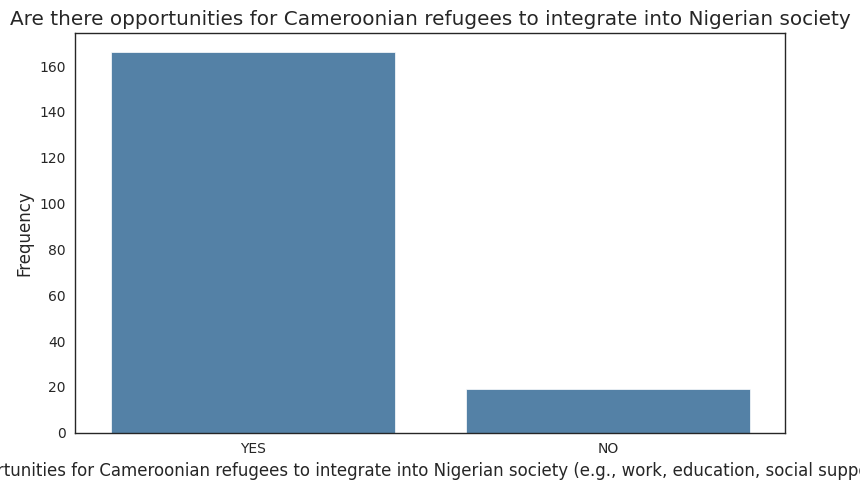

In [59]:
plot_frequency_bar(
    opportunity_table,
    category_col="Are there opportunities for Cameroonian refugees to integrate into Nigerian society (e.g., work, education, social support)? (Recoded)",
    title="Are there opportunities for Cameroonian refugees to integrate into Nigerian society"
)

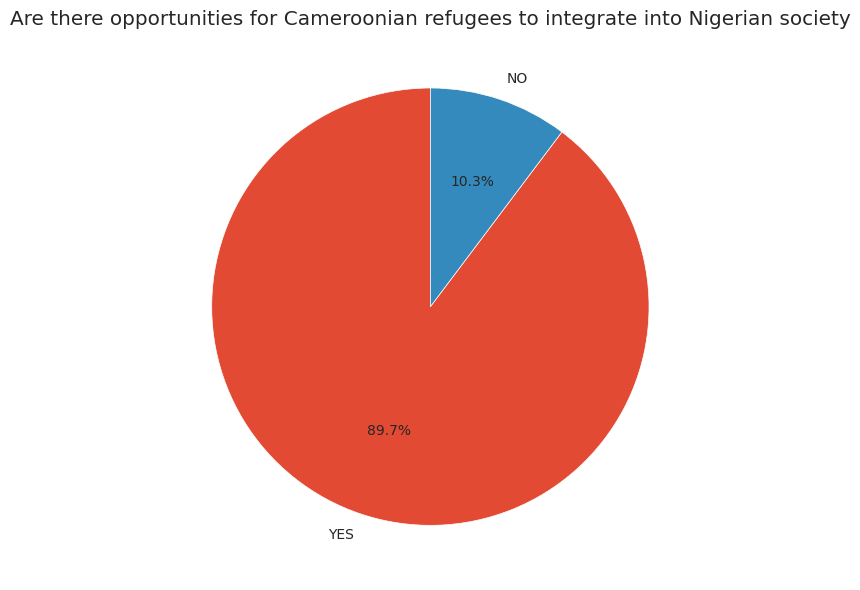

In [60]:
plot_frequency_pie(
    opportunity_table,
    category_col="Are there opportunities for Cameroonian refugees to integrate into Nigerian society (e.g., work, education, social support)? (Recoded)",
    title="Are there opportunities for Cameroonian refugees to integrate into Nigerian society"
)